In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import kurtosis, skew
from numpy import var

In [2]:
day_1 = pd.read_csv("trades_round_1_day_-1.csv", sep=';')
day_0 = pd.read_csv("trades_round_1_day_0.csv", sep=';')
day_2 = pd.read_csv("trades_round_1_day_-2.csv", sep=';')


day_1['timestamp'] += day_2['timestamp'].max() + 1
day_0['timestamp'] += day_1['timestamp'].max() + 1

combined_df = pd.concat([day_2, day_1, day_0], ignore_index=True)

print(combined_df.tail())

       timestamp  buyer  seller            symbol   currency   price  quantity
24881    2998902    NaN     NaN              KELP  SEASHELLS  2032.0         2
24882    2998902    NaN     NaN  RAINFOREST_RESIN  SEASHELLS  9995.0         2
24883    2998902    NaN     NaN         SQUID_INK  SEASHELLS  1830.0         2
24884    2999002    NaN     NaN              KELP  SEASHELLS  2032.0         1
24885    2999002    NaN     NaN         SQUID_INK  SEASHELLS  1832.0         1


In [3]:
# Filtrer les lignes avec le symbole 'SQUID_INK'
squid_ink_df = combined_df[combined_df['symbol'] == 'SQUID_INK']

squid_ink_prices = squid_ink_df[['timestamp', 'price']]
squid_ink_prices.index = range(1, len(squid_ink_prices) + 1)

print(squid_ink_prices)


      timestamp   price
1             0  2002.0
2           100  2001.0
3          1000  1999.0
4          1100  1999.0
5          1500  2000.0
...         ...     ...
8833    2997902  1840.0
8834    2998102  1840.0
8835    2998202  1831.0
8836    2998902  1830.0
8837    2999002  1832.0

[8837 rows x 2 columns]


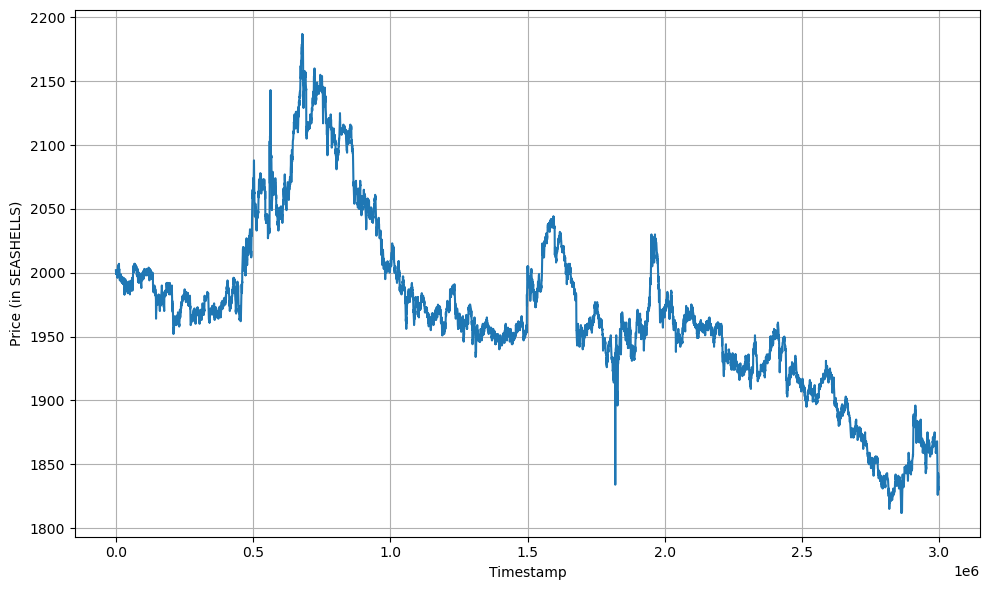

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(squid_ink_prices['timestamp'], squid_ink_prices['price'],  linestyle='-')
plt.xlabel('Timestamp')
plt.ylabel('Price (in SEASHELLS)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Testing

In [5]:
prices = squid_ink_prices['price'].dropna()

In [ ]:
for i in range(10):
    print(f"\n--- Autocorrelation (lag={i}) ---")
    autocorr = prices.autocorr(lag=i)
    print(f"Autocorrelation at lag {i}: {autocorr:.4f}")


In [ ]:
print("\n--- Box-Ljung Test ---")
ljung_box = acorr_ljungbox(prices, lags=[10], return_df=True)
print(ljung_box)
if ljung_box['lb_pvalue'].values[0] < 0.05:
    print("Interpretation: Reject null hypothesis →  exhibits autocorrelation.")
else:
    print("Interpretation: Fail to reject null → No significant autocorrelation.\n")


In [ ]:
print("\n--- Statistical Moments ---")
mean_val = np.mean(prices)
std_val = np.std(prices)
skew_val = skew(prices)
kurt_val = kurtosis(prices)
print(f"Mean: {mean_val:.2f}, Std Dev: {std_val:.2f}, Skewness: {skew_val:.4f}, Kurtosis: {kurt_val:.4f}")
print("Interpretation: Skewness ≠ 0 → Asymmetry; Kurtosis > 3 → Heavy tails.\n")


In [ ]:
from scipy.stats import zscore

squid_ink_prices['zscore'] = zscore(squid_ink_prices['price'].dropna())

# Plot
plt.figure(figsize=(12, 6))
plt.plot(squid_ink_prices.index, squid_ink_prices['zscore'], label='Z-score', color='blue')
plt.axhline(0, color='black', linestyle='--')
plt.axhline(2, color='red', linestyle='--', label='±2 threshold')
plt.axhline(-2, color='red', linestyle='--')
plt.title('Z-score of SQUID_INK Prices')
plt.xlabel('Index')
plt.ylabel('Z-score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd


squid_ink_prices['returns'] = squid_ink_prices['price'].pct_change().apply(lambda x: np.log(1 + x))


squid_ink_prices['returns_t_minus_1'] = squid_ink_prices['returns'].shift(1)


squid_ink_prices = squid_ink_prices.dropna(subset=['returns', 'returns_t_minus_1'])
print(squid_ink_prices[['returns', 'returns_t_minus_1']].head())


   returns  returns_t_minus_1
3  -0.0010            -0.0005
4   0.0000            -0.0010
5   0.0005             0.0000
6   0.0000             0.0005
7  -0.0005             0.0000


C:\Users\clem9\AppData\Local\Temp\ipykernel_26056\2289029150.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  squid_ink_prices['returns'] = squid_ink_prices['price'].pct_change().apply(lambda x: np.log(1 + x))
C:\Users\clem9\AppData\Local\Temp\ipykernel_26056\2289029150.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  squid_ink_prices['returns_t_minus_1'] = squid_ink_prices['returns'].shift(1)


<Figure size 1000x500 with 0 Axes>

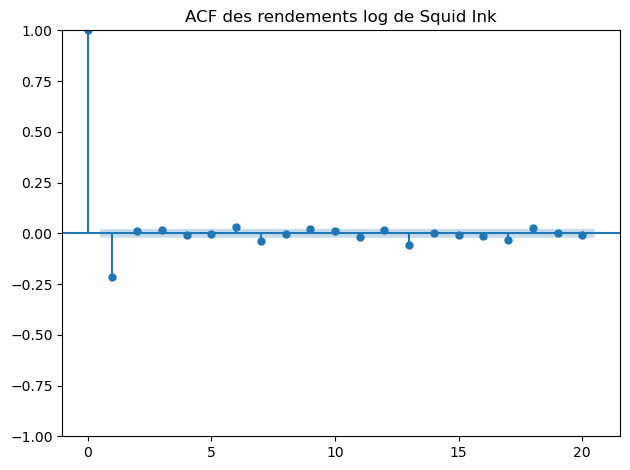

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Calcul des rendements log
squid_ink_prices['returns'] = np.log(1 + squid_ink_prices['price'].pct_change())

# Supprime les NaN
returns = squid_ink_prices['returns'].dropna()

# Trace de l'ACF
plt.figure(figsize=(10, 5))
plot_acf(returns, lags=20)  # Tu peux changer le nombre de lags si tu veux
plt.title("ACF des rendements log de Squid Ink")
plt.tight_layout()
plt.show()


# Testing linear relations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# Supposons que nous avons les prix dans une variable 'prices'
# Calculer les rendements (si ce n'est pas déjà fait)
returns = prices.pct_change()
returns = returns.dropna()  # Supprimer la première valeur qui sera NaN

# Créer les variables décalées pour la régression
X = returns.iloc[:-1].values.reshape(-1, 1)  # Rendements à t-1
y = returns.iloc[1:].values                   # Rendements à t

# Division train/test (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Entraînement du modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Prédictions sur l'ensemble d'entraînement
y_train_pred = model.predict(X_train)

# Prédictions sur l'ensemble de test
y_test_pred = model.predict(X_test)

# Évaluation du modèle
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Coefficient (pente): {model.coef_[0]:.6f}")
print(f"Constante: {model.intercept_:.6f}")
print(f"R² (train): {train_r2:.6f}")
print(f"R² (test): {test_r2:.6f}")
print(f"MSE (train): {train_mse:.6f}")
print(f"MSE (test): {test_mse:.6f}")

# Analyse plus détaillée avec statsmodels
X_train_sm = sm.add_constant(X_train)  # Ajouter une constante (intercept)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print("\nRésumé du modèle statsmodels:")
print(model_sm.summary())

# Visualisation des rendements prédits vs réels (entraînement)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'r--')
plt.title('Rendements prédits vs réels (Train)')
plt.xlabel('Rendements réels')
plt.ylabel('Rendements prédits')
plt.grid(True)

# Visualisation des rendements prédits vs réels (test)
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title('Rendements prédits vs réels (Test)')
plt.xlabel('Rendements réels')
plt.ylabel('Rendements prédits')
plt.grid(True)
plt.tight_layout()

# Convertir les rendements prédits en prix prédits
# Pour l'ensemble d'entraînement
train_prices_actual = prices.iloc[1:train_size+1].values
train_returns_pred = np.insert(y_train_pred, 0, 0)  # Insérer 0 pour le premier rendement prédit
train_prices_pred = prices.iloc[0] * np.cumprod(1 + train_returns_pred)

# Pour l'ensemble de test
test_start_idx = train_size + 1
test_prices_actual = prices.iloc[test_start_idx:test_start_idx+len(y_test)].values
test_returns_pred = np.insert(y_test_pred, 0, 0)  # Insérer 0 pour le premier rendement prédit
test_prices_pred = prices.iloc[test_start_idx-1] * np.cumprod(1 + test_returns_pred)

# Visualisation des prix réels vs prédits
plt.figure(figsize=(12, 10))

# Ensemble d'entraînement
plt.subplot(2, 1, 1)
plt.plot(range(len(train_prices_actual)), train_prices_actual, label='Prix réels (Train)', color='blue')
plt.plot(range(len(train_prices_pred)), train_prices_pred, label='Prix prédits (Train)', color='red', linestyle='--')
plt.title('Prix réels vs prédits (Ensemble d\'entraînement)')
plt.xlabel('Période')
plt.ylabel('Prix')
plt.legend()
plt.grid(True)

# Ensemble de test
plt.subplot(2, 1, 2)
plt.plot(range(len(test_prices_actual)), test_prices_actual, label='Prix réels (Test)', color='blue')
plt.plot(range(len(test_prices_pred)), test_prices_pred, label='Prix prédits (Test)', color='red', linestyle='--')
plt.title('Prix réels vs prédits (Ensemble de test)')
plt.xlabel('Période')
plt.ylabel('Prix')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Analyse des erreurs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
train_errors = y_train - y_train_pred
plt.hist(train_errors, bins=20, alpha=0.7)
plt.title('Distribution des erreurs (Train)')
plt.xlabel('Erreur')
plt.ylabel('Fréquence')
plt.grid(True)

plt.subplot(1, 2, 2)
test_errors = y_test - y_test_pred
plt.hist(test_errors, bins=20, alpha=0.7)
plt.title('Distribution des erreurs (Test)')
plt.xlabel('Erreur')
plt.ylabel('Fréquence')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Préparation des données
train_size = int(len(prices) * 0.8)
train_prices = prices[:train_size]
test_prices = prices[train_size:]

# Fonction pour calculer le R² pour une série temporelle
def r2_score_timeseries(y_true, y_pred):
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

# 1. Simple Exponential Smoothing (SES)
# Optimisation automatique du paramètre alpha
ses_model = SimpleExpSmoothing(train_prices).fit(optimized=True)
alpha = ses_model.params['smoothing_level']
print(f"Lissage exponentiel simple (SES) - Alpha optimisé: {alpha:.4f}")
print(ses_model.summary())

# Prédictions sur l'ensemble d'entraînement
train_predictions_ses = ses_model.fittedvalues

# Prédictions sur l'ensemble de test par lissage pas à pas
test_predictions_ses = []
history = list(train_prices)
last_level = ses_model.params['smoothing_level'] * train_prices.iloc[-1] + \
             (1 - ses_model.params['smoothing_level']) * train_predictions_ses.iloc[-1]

for t in range(len(test_prices)):
    # Faire une prédiction pour la prochaine période
    yhat = last_level
    test_predictions_ses.append(yhat)
    
    # Mettre à jour le niveau avec la nouvelle observation
    observed = test_prices.iloc[t]
    last_level = alpha * observed + (1 - alpha) * last_level
    
    # Ajouter l'observation à l'historique
    history.append(observed)
    
    # Afficher la progression
    if t % 20 == 0 or t == len(test_prices) - 1:
        print(f"SES - Prédiction {t+1}/{len(test_prices)} complétée")

# Convertir la liste en Series
test_predictions_ses = pd.Series(test_predictions_ses, index=test_prices.index)




# Évaluation des modèles
# SES
train_mse_ses = mean_squared_error(train_prices, train_predictions_ses)
test_mse_ses = mean_squared_error(test_prices, test_predictions_ses)
train_r2_ses = r2_score_timeseries(train_prices, train_predictions_ses)
test_r2_ses = r2_score_timeseries(test_prices, test_predictions_ses)

print(f"\nModèle SES:")
print(f"MSE (train): {train_mse_ses:.6f}")
print(f"MSE (test): {test_mse_ses:.6f}")
print(f"R² (train): {train_r2_ses:.6f}")
print(f"R² (test): {test_r2_ses:.6f}")


# Visualisation des résultats
# Comparaison des deux modèles sur l'ensemble d'entraînement
plt.figure(figsize=(15, 10))

# Ensemble d'entraînement
plt.subplot(2, 1, 1)
plt.plot(train_prices.index, train_prices, label='Prix réels (Train)', color='blue')
plt.plot(train_prices.index, train_predictions_ses, label='SES', color='red', linestyle='--')
plt.title('Prix réels vs prédits (Ensemble d\'entraînement)')
plt.xlabel('Période')
plt.ylabel('Prix')
plt.legend()
plt.grid(True)

# Ensemble de test
plt.subplot(2, 1, 2)
plt.plot(test_prices.index, test_prices, label='Prix réels (Test)', color='blue')
plt.plot(test_prices.index, test_predictions_ses, label='SES', color='red', linestyle='--')
plt.title('Prix réels vs prédits (Ensemble de test)')
plt.xlabel('Période')
plt.ylabel('Prix')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Entraîner le modèle ARIMA sur les retours log
arima_model = ARIMA(X_train, order=(1, 0, 0))  # (p, d, q) - ajuster selon les données
arima_model_fit = arima_model.fit()


train_predictions_arima_returns_log = arima_model_fit.fittedvalues

# Visualisation des retours log réels vs prédictions ARIMA sur l'entraînement
plt.figure(figsize=(12, 6))
plt.plot(returns.iloc[:train_size-1:].index,X_train, label='Retours log réels (Entraînement)', color='blue')
plt.plot(returns.iloc[:train_size-1:].index, train_predictions_arima_returns_log, label='Prédictions ARIMA sur les retours log (Entraînement)', color='red', linestyle='--')
plt.title('Retours log réels vs Prédictions ARIMA sur l\'ensemble d\'entraînement')
plt.xlabel('Période')
plt.ylabel('Retours log')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
print(X_train[0])

In [ ]:
X_trai

In [ ]:
# Calcul des prix simulés à partir des retours log prédits (en cumulé)
simulated_prices_train = np.exp(np.cumsum(train_predictions_arima_returns_log)) * prices[0]


# Visualisation des prix simulés et réels sur l'entraînement
plt.figure(figsize=(12, 6))
plt.plot(returns.iloc[:train_size-1:].index, prices[:train_size-1], label='Prix réels (Entraînement)', color='blue')
plt.plot(returns.iloc[:train_size-1:].index, simulated_prices_train, label='Prix simulés ARIMA (Entraînement)', color='red', linestyle='--')
plt.title('Prix réels vs Prix simulés ARIMA sur l\'ensemble d\'entraînement')
plt.xlabel('Période')
plt.ylabel('Prix')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

# Prédictions des retours log sur l'ensemble de test
test_predictions_arima_returns_log = arima_model_fit.forecast(len(X_test))

# Calcul des prix simulés pour le test
simulated_prices_test = np.exp(np.cumsum(test_predictions_arima_returns_log)) * X_train[-1]

# Visualisation des prix simulés et réels sur le test
plt.figure(figsize=(12, 6))
plt.plot(, X_test, label='Prix réels (Test)', color='blue')
plt.plot(, simulated_prices_test, label='Prix simulés ARIMA (Test)', color='red', linestyle='--')
plt.title('Prix réels vs Prix simulés ARIMA sur l\'ensemble de test')
plt.xlabel('Période')
plt.ylabel('Prix')
plt.legend()
plt.grid(True)
plt.show()

# Affichage du résumé du modèle ARIMA
print(arima_model_fit.summary())
